<a href="https://colab.research.google.com/github/Keshavanand20/Machine_Learning/blob/main/Support_vector_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Essential Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

# Importing the Dataset

In [2]:
df = pd.read_csv("/content/Student_Marks.csv")

#EDA


In [3]:
df.head()


,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [4]:
df.describe()

,number_courses,time_study,Marks
count,100.000000,100.000000,100.000000
mean,5.290000,4.077140,24.417690
std,1.799523,2.372914,14.326199
min,3.000000,0.096000,5.609000
25%,4.000000,2.058500,12.633000
50%,5.000000,4.022000,20.059500
75%,7.000000,6.179250,36.676250
max,8.000000,7.957000,55.299000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [6]:
df.isnull().sum()

,0
number_courses,0
time_study,0
Marks,0


Text(0.5, 1.0, 'Hours studied v/s Marks')

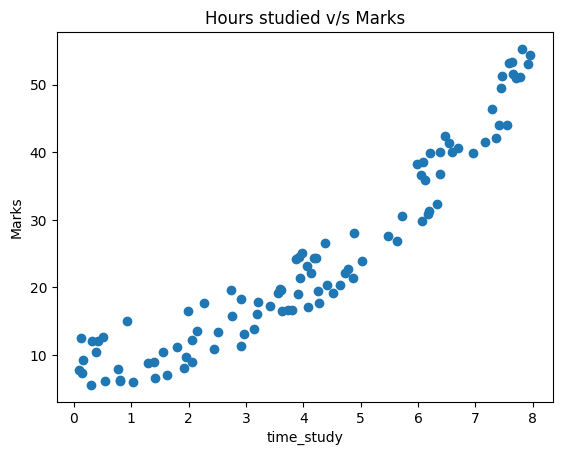

In [7]:
plt.scatter(df['time_study'],df['Marks'])
plt.xlabel('time_study')
plt.ylabel('Marks')
plt.title('Hours studied v/s Marks')

In [8]:
df.columns.get_loc('time_study')

1

In [9]:
#if you want to change the name of column
df.rename(columns={'time_study':'Hours'},inplace=True)

In [10]:
df


,number_courses,Hours,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299
...,...,...,...
95,6,3.561,19.128
96,3,0.301,5.609
97,4,7.163,41.444
98,7,0.309,12.027


<Axes: >

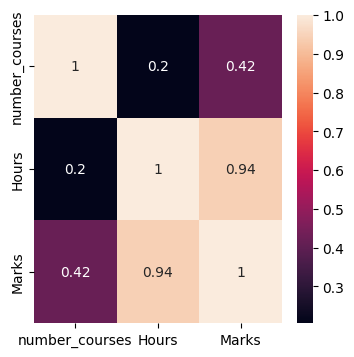

In [11]:
plt.figure(figsize=(4,4))
sns.heatmap(df.corr(), color='indigo', annot= True)

# Feature Scaling
 * Standardization: This method will scale down the values between -1 and 1 where 0 is the mean of the values. It tells how much a value is deviating from the mean value.
 * Normalization: This method will scale down the value from 0 to 1.

In [12]:
df.head()

,number_courses,Hours,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [29]:
#x = np.array(df.Hours)
#y = np.array(df.Marks)
#the above can be written as
x = df.iloc[:,1].values
y = df.iloc[:,-1].values #df.iloc[rows,columns]

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [32]:
#standard scalar requires 2D array to process so we have to reshape both the x and y arrays
x = scaler.fit_transform(x.reshape(-1,1))
y = scaler.fit_transform(y.reshape(-1,1))

In [37]:
print(x) #as we can see the values have been standardised from -1 to 1

[[ 0.18248894]
 [-1.68619512]
 [-0.39988653]
 [ 1.6229682 ]
 [ 1.58146071]
 [-0.36684996]
 [ 0.84110266]
 [-0.28129371]
 [ 0.14098145]
 [ 0.8876927 ]
 [ 1.38747674]
 [-1.54769564]
 [ 0.05966066]
 [ 0.08337923]
 [-0.49518433]
 [ 0.07744958]
 [ 0.6954029 ]
 [ 0.84830294]
 [ 1.53910613]
 [-0.04241388]
 [ 0.27778675]
 [ 0.86778604]
 [-0.85816308]
 [ 0.33793025]
 [-0.18726654]
 [-1.13092658]
 [-1.51169425]
 [ 0.12742799]
 [-1.66078237]
 [-1.17666952]
 [-0.09027455]
 [-0.91237695]
 [-1.33211083]
 [ 1.06600548]
 [ 0.00248198]
 [ 1.46795044]
 [-0.47061868]
 [ 1.35782853]
 [ 1.04016918]
 [ 1.56621307]
 [-1.6675591 ]
 [-0.56041039]
 [-0.20590255]
 [-1.06739471]
 [-0.89924703]
 [-0.85392763]
 [-0.11865212]
 [ 0.29726985]
 [ 0.65982506]
 [-0.06952081]
 [ 1.11217197]
 [ 0.02238863]
 [-1.40030171]
 [ 0.83517302]
 [ 1.48828064]
 [-0.49306661]
 [ 1.50945793]
 [ 1.51284629]
 [ 0.89828134]
 [ 1.43618451]
 [-1.5676023 ]
 [-0.69425086]
 [-0.19954937]
 [ 0.33538898]
 [-1.67179456]
 [-0.81962042]
 [ 0.59121

Splitting the data for training the model

In [38]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=10)

In [39]:
x_train.shape #this is a 2d data

(80, 1)

Define the model that'll be used

In [40]:
from  sklearn.svm import SVR

In [42]:
model = SVR(kernel = 'rbf')

In [43]:
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

In [44]:
y_pred = model.predict(x_test)

In [45]:
y_pred

array([-0.28927074, -0.58254104, -1.11209494,  1.61793607,  0.23828831,
        1.88562622, -1.17712111, -0.64218564,  1.04806879, -1.14988499,
       -0.5035211 , -0.97391705, -1.08137331,  0.64682394, -0.38164286,
        1.38912494,  0.00784071, -1.12056524,  1.72312854, -0.32741422])

In [46]:
y_test

array([[ 0.05018174],
       [-0.91345138],
       [-0.98136029],
       [ 1.54586157],
       [ 0.22107649],
       [ 2.00642152],
       [-1.26758795],
       [-0.60982557],
       [ 1.18842777],
       [-1.08722244],
       [-0.74410001],
       [-1.17042489],
       [-0.97483599],
       [ 0.85835396],
       [-0.37109206],
       [ 1.08979147],
       [-0.03519548],
       [-0.82575908],
       [ 1.88891384],
       [-0.54121511]])

convert the values back to the normal form

In [51]:
y_pred = y_pred.reshape(-1,1)
y_test = y_test.reshape(-1,1)
y_pred = scaler.inverse_transform(y_pred)
y_test = scaler.inverse_transform(y_test)

<function matplotlib.pyplot.show(close=None, block=None)>

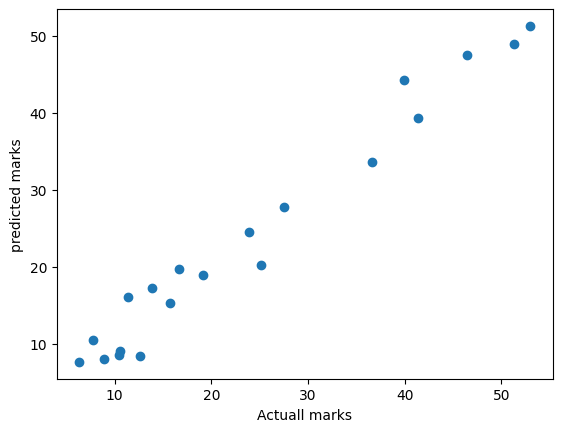

In [54]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actuall marks')
plt.ylabel('predicted marks')
plt.show

let's find the accuracy

In [55]:
r2_score(y_test,y_pred)

0.9686463560293465

In [57]:
mean_squared_error(y_test, y_pred)

7.101621247150634

In [58]:
mean_absolute_error(y_test, y_pred)

2.2233241367860033